# Step 7: Summary

Which numerical choices create the most spurious mixing in the lock exchange? This notebook collects every run from steps 2 to 6 into one table, makes one summary figure, and states the conclusions.

I load the libraries and shared functions. I read every run folder directly rather than the step tables, so that all runs are treated the same way; the step 1 test run is left out.

In [1]:
%matplotlib inline

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mixing_tools import (RUNS, DELTA_B, DEPTH, LENGTH, load_run, rpe_series, buoyancy_variance, front_positions,
                          front_speed, rpe_rate_at, density)

U_FRONT = 0.5 * np.sqrt(DELTA_B * DEPTH)        # front speed used for the grid Reynolds number (m/s)
FIT_START, FIT_END = 3 * 3600, 15 * 3600
FIG_DIR = "../figures"
DATA_DIR = "../data"
names = sorted(n for n in os.listdir(RUNS) if os.path.isdir(os.path.join(RUNS, n)) and not n.startswith("step1"))
print(len(names), "runs:", ", ".join(names))

34 runs: step2_baseline_weno, step3_tracer_centered2, step3_tracer_centered2_wide_limit, step3_tracer_upwind3, step4_centered2_dx1000, step4_centered2_dx125, step4_centered2_dx2000, step4_centered2_dx250, step4_weno5_dx1000, step4_weno5_dx125, step4_weno5_dx2000, step4_weno5_dx250, step5_cmom_nu0p01, step5_cmom_nu0p1, step5_cmom_nu100p0, step5_cmom_nu10p0, step5_cmom_nu1p0, step5_cmom_nu200p0, step5_wmom_nu0p1, step5_wmom_nu100p0, step5_wmom_nu10p0, step5_wmom_nu1p0, step5_wmom_nu200p0, step6_adaptive_cfl0p5, step6_fixed_cfl0p2, step6_fixed_cfl0p5, step6_fixed_cfl1p0, step6_fixed_cfl1p5, step6_fixed_cfl2p0, step6_fixed_cfl2p0_nan_only, step6_fixed_cfl2p5, step6_fixed_cfl2p5_nan_only, step6_fixed_cfl3p0, step6_fixed_cfl4p0


The summary table: one row per run, with the settings, the grid Reynolds number, the largest measured advective CFL number, and the results at 17 h (for runs that finished). For runs whose tracer scheme created new extremes (steps 3 and 4), the RPE change is not a fair measure of mixing, because the new extremes can lower the RPE. The table flags these with `rpe_valid = False`: RPE fell between two snapshots by more than 1% of its total change over the run. (Tiny falls of about 1e-8 of the RPE, from rounding and from the coarse 2000 m grid, are allowed.)

In [2]:
rows = []
for name in names:
    ds, log, info = load_run(name)
    dx = float(info["dx_m"])
    nu = float(info["nu_h_m2_s"])
    row = {"run": name, "tracer_scheme": info["tracer_advection"], "momentum_scheme": info["momentum_advection"],
           "dx_m": dx, "dz_m": float(info["dz_m"]), "nu_h_m2_s": nu, "grid_reynolds": U_FRONT * dx / nu,
           "time_stepping": info["time_stepping"], "max_cfl": log["advective_cfl"].max(), "status": info["status"],
           "overshoot": max(log["b_max"].max() - DELTA_B, -log["b_min"].min(), 0) / DELTA_B,
           "total_b_drift": np.max(np.abs(log["b_total_m3_per_s2"] - log["b_total_m3_per_s2"].iloc[0])) / log["b_total_m3_per_s2"].iloc[0],
           "uniform_tracer_deviation": float(info.get("consistency_tracer_max_deviation", "nan")),
           "iterations": int(info["iterations"]), "wall_time_s": float(info["wall_time_s"])}
    if info["status"] == "completed":
        times = ds.time.values
        rpe = rpe_series(ds)
        variance = buoyancy_variance(ds)
        right, left = front_positions(ds)
        row.update({"rpe_change_17h": (rpe[-1] - rpe[0]) / rpe[0],
                    "drpe_dt_17h_W_m2": rpe_rate_at(times, rpe, 17 * 3600, 3600) / LENGTH,
                    "rpe_smallest_step": np.min(np.diff(rpe)) / rpe[0],
                    "rpe_valid": bool(np.min(np.diff(rpe)) > -0.01 * abs(rpe[-1] - rpe[0])),
                    "variance_change_17h": (variance[-1] - variance[0]) / variance[0],
                    "front_speed_m_s": front_speed(times, right, FIT_START, FIT_END)})
    rows.append(row)
summary = pd.DataFrame(rows)
summary.to_csv(os.path.join(DATA_DIR, "summary_all_runs.csv"), index=False)
pd.set_option("display.width", 260)
pd.set_option("display.max_rows", 100)
cols = ["run", "tracer_scheme", "momentum_scheme", "dx_m", "nu_h_m2_s", "grid_reynolds", "max_cfl", "rpe_change_17h",
        "rpe_valid", "variance_change_17h", "overshoot", "front_speed_m_s", "wall_time_s"]
print(summary[cols].to_string(index=False, float_format=lambda v: f"{v:.3g}"))
print()
print(f"{len(summary)} runs, {np.sum(summary['status'] == 'completed')} completed, "
      f"{np.sum(summary['status'] != 'completed')} stopped by the health check")
print(f"total buoyancy drift in any run: at most {summary['total_b_drift'].max():.1e}; "
      f"uniform tracer deviation: at most {summary['uniform_tracer_deviation'].max():.1e}")
print(f"total wall time of all runs: {summary['wall_time_s'].sum() / 60:.1f} minutes (the first run of each script includes ~20 s of compiling)")

                              run         tracer_scheme   momentum_scheme  dx_m  nu_h_m2_s  grid_reynolds  max_cfl  rpe_change_17h rpe_valid  variance_change_17h  overshoot  front_speed_m_s  wall_time_s
              step2_baseline_weno         WENO(order=5)     WENO(order=5)   500       0.01       2.48e+04    0.257        3.54e-05      True               -0.186   0.000211            0.479         21.3
           step3_tracer_centered2     Centered(order=2)     WENO(order=5)   500       0.01       2.48e+04    0.244             NaN       NaN                  NaN       1.01              NaN         20.7
step3_tracer_centered2_wide_limit     Centered(order=2)     WENO(order=5)   500       0.01       2.48e+04    0.299       -9.49e-05     False               0.0075       2.74            0.513         0.64
             step3_tracer_upwind3 UpwindBiased(order=3)     WENO(order=5)   500       0.01       2.48e+04    0.255        1.58e-05     False               -0.152      0.379            0.48

The summary figure. Each bar is one choice, changed from the baseline (WENO tracer and momentum, dx = 500 m, nu_h = 0.01 m^2/s, adaptive time step), and shows by how much it changes the total spurious mixing over the 17 hours (the RPE change, relative to the baseline; left) and the largest overshoot (right). For the centred and upwind-biased tracer schemes the RPE is not a fair measure (it is lowered by their new extremes), so their left bars are left out and only their overshoots are shown.

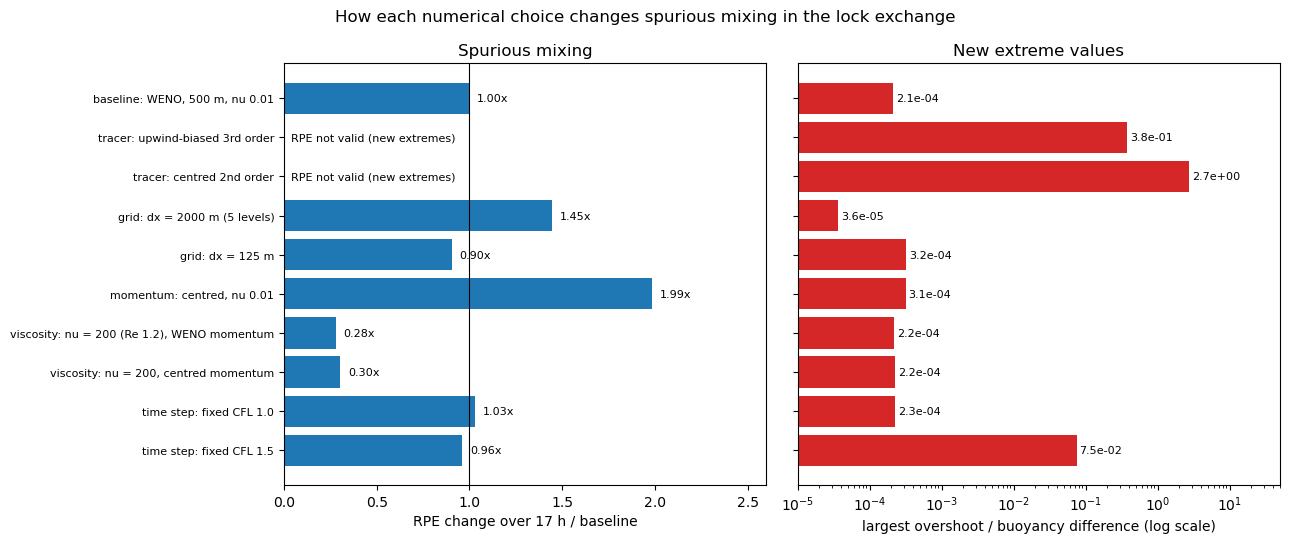

baseline: WENO, 500 m, nu 0.01      RPE change   1.00 x baseline | overshoot 2.1e-04
tracer: upwind-biased 3rd order     RPE change    nan x baseline | overshoot 3.8e-01
tracer: centred 2nd order           RPE change    nan x baseline | overshoot 2.7e+00
grid: dx = 2000 m (5 levels)        RPE change   1.45 x baseline | overshoot 3.6e-05
grid: dx = 125 m                    RPE change   0.90 x baseline | overshoot 3.2e-04
momentum: centred, nu 0.01          RPE change   1.99 x baseline | overshoot 3.1e-04
viscosity: nu = 200 (Re 1.2), WENO momentum RPE change   0.28 x baseline | overshoot 2.2e-04
viscosity: nu = 200, centred momentum RPE change   0.30 x baseline | overshoot 2.2e-04
time step: fixed CFL 1.0            RPE change   1.03 x baseline | overshoot 2.3e-04
time step: fixed CFL 1.5            RPE change   0.96 x baseline | overshoot 7.5e-02


In [3]:
choices = [("baseline: WENO, 500 m, nu 0.01", "step2_baseline_weno"),
           ("tracer: upwind-biased 3rd order", "step3_tracer_upwind3"),
           ("tracer: centred 2nd order", "step3_tracer_centered2_wide_limit"),
           ("grid: dx = 2000 m (5 levels)", "step4_weno5_dx2000"),
           ("grid: dx = 125 m", "step4_weno5_dx125"),
           ("momentum: centred, nu 0.01", "step5_cmom_nu0p01"),
           ("viscosity: nu = 200 (Re 1.2), WENO momentum", "step5_wmom_nu200p0"),
           ("viscosity: nu = 200, centred momentum", "step5_cmom_nu200p0"),
           ("time step: fixed CFL 1.0", "step6_fixed_cfl1p0"),
           ("time step: fixed CFL 1.5", "step6_fixed_cfl1p5")]
by_run = summary.set_index("run")
base_rate_value = by_run.loc["step2_baseline_weno", "drpe_dt_17h_W_m2"]
base_change = by_run.loc["step2_baseline_weno", "rpe_change_17h"]
labels = [c[0] for c in choices]
ratios = []
overshoots = []
for label, run in choices:
    r = by_run.loc[run]
    ratios.append(r["rpe_change_17h"] / base_change if r["rpe_valid"] else np.nan)
    overshoots.append(r["overshoot"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
ypos = np.arange(len(choices))[::-1]
axes[0].barh(ypos, ratios, color="tab:blue")
axes[0].axvline(1.0, color="k", lw=0.8)
axes[0].set_xlim(0, 2.6)
axes[0].set_xlabel("RPE change over 17 h / baseline")
axes[0].set_title("Spurious mixing")
for y, value in zip(ypos, ratios):
    axes[0].text(value + 0.04 if np.isfinite(value) else 0.04, y,
                 f"{value:.2f}x" if np.isfinite(value) else "RPE not valid (new extremes)", va="center", fontsize=8)
axes[1].barh(ypos, overshoots, color="tab:red")
axes[1].set_xscale("log")
axes[1].set_xlim(1e-5, 50)
axes[1].set_xlabel("largest overshoot / buoyancy difference (log scale)")
axes[1].set_title("New extreme values")
for y, value in zip(ypos, overshoots):
    axes[1].text(value * 1.1, y, f"{value:.1e}", va="center", fontsize=8)
axes[0].set_yticks(ypos)
axes[0].set_yticklabels(labels, fontsize=8)
fig.suptitle("How each numerical choice changes spurious mixing in the lock exchange")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "07_summary.png"), dpi=150)
plt.show()
for label, ratio, over in zip(labels, ratios, overshoots):
    print(f"{label:35s} RPE change {ratio:6.2f} x baseline | overshoot {over:.1e}")

The numbers I quote in the conclusions, computed here so they can be traced.

In [4]:
def value(run, column):
    return by_run.loc[run, column]

for scheme in ["cmom", "wmom"]:
    low = "step5_cmom_nu0p01" if scheme == "cmom" else "step2_baseline_weno"
    high = f"step5_{scheme}_nu200p0"
    print(f"{scheme}: nu 0.01 -> 200: dRPE/dt at 17 h falls by {value(low, 'drpe_dt_17h_W_m2') / value(high, 'drpe_dt_17h_W_m2'):.1f}x, "
          f"RPE change by {value(low, 'rpe_change_17h') / value(high, 'rpe_change_17h'):.1f}x")
print(f"centred / WENO momentum at nu 0.01: dRPE/dt {value('step5_cmom_nu0p01', 'drpe_dt_17h_W_m2') / base_rate_value:.2f}x, "
      f"RPE change {value('step5_cmom_nu0p01', 'rpe_change_17h') / base_change:.2f}x")
print(f"WENO tracer, dx 2000 -> 125 m: RPE change falls by {value('step4_weno5_dx2000', 'rpe_change_17h') / value('step4_weno5_dx125', 'rpe_change_17h'):.2f}x")
print(f"centred tracer overshoot: {value('step4_centered2_dx2000', 'overshoot'):.2f} (2000 m) to {value('step4_centered2_dx125', 'overshoot'):.2f} (125 m)")
valid = summary[summary["rpe_valid"] == True]
print("runs with rpe_valid = False:", ", ".join(summary.loc[summary["rpe_valid"] == False, "run"]))

cmom: nu 0.01 -> 200: dRPE/dt at 17 h falls by 8.6x, RPE change by 6.5x
wmom: nu 0.01 -> 200: dRPE/dt at 17 h falls by 4.3x, RPE change by 3.5x
centred / WENO momentum at nu 0.01: dRPE/dt 2.15x, RPE change 1.99x
WENO tracer, dx 2000 -> 125 m: RPE change falls by 1.60x
centred tracer overshoot: 0.81 (2000 m) to 5.85 (125 m)
runs with rpe_valid = False: step3_tracer_centered2_wide_limit, step3_tracer_upwind3, step4_centered2_dx1000, step4_centered2_dx125, step4_centered2_dx2000, step4_centered2_dx250, step6_fixed_cfl2p0_nan_only


## Conclusions in plain words

- The momentum settings mattered most for how much the water masses were mixed. With the same WENO tracer scheme and centred momentum, raising the viscosity from 0.01 to 200 m^2/s (grid Reynolds number 24 761 to 1.2) cut the mixing rate at 17 h by a factor of 8.6 and the total RPE change by 6.5. At low viscosity, WENO momentum instead of centred momentum halved the mixing (a factor of 2.0 to 2.2). Grid-scale noise in the velocity, which the viscosity and the momentum scheme control, followed the mixing (step 5). This agrees with Ilicak et al. (2012).
- The tracer scheme decided whether the model invents new water masses. Only WENO stayed within the starting range. The centred scheme made values 2.7 buoyancy differences outside it at 500 m, and 5.8 at 125 m (steps 3 and 4). For such schemes a single mixing number is misleading, because the new extremes lower the RPE.
- A finer grid helped little while the grid Reynolds number stayed far above 100. Going 16 times finer reduced the WENO mixing by a factor of only 1.6, and from 500 m to 125 m by only 10% (step 4).
- The time step hardly mattered up to a CFL number of about 1. Above that it first created new extremes (CFL 1.5 and 2.0) and then broke the run (CFL 2.5 and higher) (step 6).
- Overall: the most spurious mixing came from a low viscosity (a high grid Reynolds number) with a non-dissipative momentum scheme, and the worst water masses came from a non-monotone tracer scheme.

Why this matters for climate models: a long simulation runs for centuries, and spurious mixing acts all the time. Mixing the interface between water masses lifts dense water and lowers light water, which weakens the stratification and raises the potential energy, as the RPE shows. Over centuries this can erode water-mass properties and change the deep density differences that drive the overturning circulation, which is why numerical mixing has to be measured and kept well below the physical mixing a model is meant to represent. This test only shows the mechanism in a 2D, 17-hour setting; it does not measure the size of the effect in a climate model.